In [1]:
import datetime
import sys, os, logging

from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline 
from pathlib import Path

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")

# Project root
PROJECT_ROOT = Path(os.path.abspath("../../.."))
sys.path.insert(0, str(PROJECT_ROOT))

from inference.prefilter_model.utils import list_h5_parts, load_model, load_mc_test_parts, \
    load_exp_parts, predict_scores, plot_event_3d, load_blind_reco

%load_ext autoreload
%autoreload 2

In [2]:
# ── Paths ──

MODEL_NAME = "da_prefilter_numu_260429_0155_Qclip_softlabels_PlateauLR_lambda0.05_MC2M_dmodel128_zflipBothMCExp_SoftFocalLoss"
PREDS_PATH = f"../test_exp_reco_mc_reco/{MODEL_NAME}/exp.parquet"

#EXP_RECO_H5_PATH = "data_manager/data/h5datasets/exp_reco.h5"
BLIND_ANALYSIS_ROOTS = "data_manager/data/exp_reco_root/reco_blind_files"

# ── Figures output directory ──
FIGURES_DIR = PROJECT_ROOT / f"experiments/numu/{MODEL_NAME}/figures_test_expnureco"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(fig, filename: str, rewrite=True) -> None:
    """Save figure to FIGURES_DIR; raise FileExistsError if already present."""
    fig_path = FIGURES_DIR / filename
    if not rewrite and fig_path.exists():
        raise FileExistsError(f"Figure already exists: {fig_path}")
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {fig_path}")

# ── MC test parts to load (from complement of training parts) ──
N_PARTS_PER_PARTICLE = {
    "muatm": 16,
    "nue2": 8,
    "nuatm": 8,
}

# reco_parts = list_h5_parts(str(PROJECT_ROOT / EXP_RECO_H5_PATH), 'exp_reco')
# BAD_RECO_PARTS = [
#     p for p in reco_parts if 'c01' in p
# ]

# ── Inference settings ──
DEVICE = "cuda:4"
BATCH_SIZE = 1024
MAX_HITS = 500
SEED = 42

# ── reco_prty column mapping (index -> name) (jsut in case) ──
RECO_EVENTS_COLUMNS = {
    0: "fThetaRec",
    1: "fPhiRec",
    2: "fThetaErr",
    3: "fPhiErr",
    4: "fFuncValue",
    5: "fTimeChi2",
    6: "fChargeTerm",
    7: "fLLFit",
    8: "fNHits",
    9: "fNStrings",
    10: "fNOMs",
    11: "fPathLength",
    12: "fTimeXYZRec",
    13: "fCovMatrixStatus",
    14: "fScfMaxTheta",
    15: "fScfMinTheta",
    16: "fScfTheta",
    17: "fScfPhi",
    18: "fPHit",
    19: "fEvCenterZ",
    20: "fZDist",
    21: "fNTriplets",
    22: "fNCalls",
    23: "fClassBDT", # Just placeholders...
    24: "fClassBDTLowE", # Just placeholders...
}
RECO_HITS_COLUMNS = { 
    0: "fTRes" # Unmatchable with other hits data!!!
}

# Load data

In [3]:
import pyarrow.parquet as pq

ARRAY_COLS = {"features", "signal_mask", "reco_hit_prty"}

# Inspect available columns without reading data
schema = pq.read_schema(PREDS_PATH)
scalar_cols = [c for c in schema.names if c not in ARRAY_COLS]

# Read only scalar columns — array columns never touch RAM
df_exp_reco = pq.read_table(PREDS_PATH, columns=scalar_cols).to_pandas()

In [4]:
df_exp_reco.head()

,h5_part_str,local_id,n_hits,max_q,mean_z,n_signal_hits_reco,n_signal_strings_reco,season,cluster,run,...,scfTheta,scfPhi,pHit,evCenterZ,zDist,nTriplets,nCalls,classBDT,classBDTLowE,score
0,part_s2020_c02_r0002,0,73,20.361805,96.249599,8,2,2020,2,2,...,2.199115,3.246311,1.481511e-05,463.458710,166.204910,2.0,101.0,-2.0,-2.0,0.015710
1,part_s2020_c02_r0002,1,69,5.650789,67.239399,4,1,2020,2,2,...,2.932152,5.340704,2.343607e-06,576.408997,291.790466,2.0,88.0,-2.0,-2.0,0.011704
2,part_s2020_c02_r0002,2,61,6.810416,57.830026,7,1,2020,2,2,...,2.513274,3.769909,9.778952e-04,453.307373,189.387177,1.0,360.0,-2.0,-2.0,0.009606
3,part_s2020_c02_r0002,3,56,10.796556,7.594438,7,2,2020,2,2,...,2.513274,5.864302,6.874379e-03,204.894745,128.071625,4.0,139.0,-2.0,-2.0,0.006473
4,part_s2020_c02_r0002,4,67,20.846405,102.072703,9,2,2020,2,2,...,2.617993,1.570796,8.614747e-07,516.204468,271.404449,2.0,167.0,-2.0,-2.0,0.020149


In [5]:
# import pyarrow.parquet as pqs
# # ARRAY_COLS = {"features", "signal_mask", "reco_hit_prty"}

# df_exp_reco = pd.read_parquet(PREDS_PATH)
# print(f"Exp: {len(df_exp_reco):,} events")
# print(df_exp_reco[['season', 'cluster', 'run', 'event_id_cc', 'n_hits']].head(3))

In [6]:
# Already filtered
# df_exp_reco = df_exp_reco[(~df_exp_reco['h5_part_str'].str.contains('c01'))]

## Filter events having max Q >1e4 ev
if 'max_q' in df_exp_reco.columns:
    maxq = df_exp_reco['max_q']
    df_exp_reco = df_exp_reco[maxq <= 1e4]#.reset_index(drop=True)

## Blind analysis results

In [7]:
df_analysis = load_blind_reco(
    blind_reco_dir=str(PROJECT_ROOT / BLIND_ANALYSIS_ROOTS),
    prelcuts_only=True,
    max_files=None
)
df_analysis_filt = df_analysis[df_analysis['fPrelCutsPassed'].astype(bool)]

Loading blind reco:   0%|          | 0/1774 [00:00<?, ?file/s]

2026-05-03 18:48:16,533 WARNING Skipping corrupt file murecAnalysis_blind_prelCuts_2020_cl3_run290_scl_nu_DATA2020.root: expected Chunk of length 403,
received 0 bytes from FSSpecSource
for file path /home/albert/Baikal2025/data_manager/data/exp_reco_root/reco_blind_files/murecAnalysis_blind_prelCuts_2020_cl3_run290_scl_nu_DATA2020.root
2026-05-03 18:48:36,830 WARNING Skipping corrupt file murecAnalysis_blind_prelCuts_2020_cl6_run458_scl_nu_DATA2020.root: expected Chunk of length 403,
received 0 bytes from FSSpecSource
for file path /home/albert/Baikal2025/data_manager/data/exp_reco_root/reco_blind_files/murecAnalysis_blind_prelCuts_2020_cl6_run458_scl_nu_DATA2020.root
2026-05-03 18:48:36,832 WARNING Skipping corrupt file murecAnalysis_blind_prelCuts_2020_cl6_run45_scl_nu_DATA2020.root: expected Chunk of length 403,
received 0 bytes from FSSpecSource
for file path /home/albert/Baikal2025/data_manager/data/exp_reco_root/reco_blind_files/murecAnalysis_blind_prelCuts_2020_cl6_run45_scl_nu

## Filter and merge reco exp events to have preliminary cuts

In [8]:
df_main = df_exp_reco.merge(df_analysis_filt, on=['season', 'cluster', 'run', 'event_id_cc'], how='inner')
len(df_main), len(df_analysis_filt), len(df_exp_reco), len(df_analysis)

(94607, 99228, 68463123, 99228)

# Plots

In [9]:
# ── BDT category masks ───────────────────────────────────────────────────────
bdt = df_main["fBDT_v3_LE"]
mask_nu  = bdt >= 0.4          # BDT-certain neutrinos
mask_mu  = bdt <= -0.4         # BDT-certain muons
mask_unc = (bdt > -0.4) & (bdt < 0.4)   # BDT-uncertain events

n_all = len(df_main)
n_nu, n_mu, n_unc = mask_nu.sum(), mask_mu.sum(), mask_unc.sum()

print(f"Total prelim-cut events : {n_all:,}")
print(f"  BDT ≥  0.4 (ν-like)  : {n_nu:,}  ({100*n_nu/n_all:.1f}%)")
print(f"  BDT ≤ -0.4 (μ-like)  : {n_mu:,}  ({100*n_mu/n_all:.1f}%)")
print(f"  |BDT| < 0.4 (unclear) : {n_unc:,}  ({100*n_unc/n_all:.1f}%)")

Total prelim-cut events : 94,607
  BDT ≥  0.4 (ν-like)  : 125  (0.1%)
  BDT ≤ -0.4 (μ-like)  : 584  (0.6%)
  |BDT| < 0.4 (unclear) : 93,898  (99.3%)


Saved: /home/albert/Baikal2025/experiments/numu/da_prefilter_numu_260410_1119_Qclip_softlabels_PlateauLR_lambda0.3_MC2M_dmodel128_zflipBothMCExp_FocalLoss/figures_test_expnureco/preds_distr_bdt_groups.png


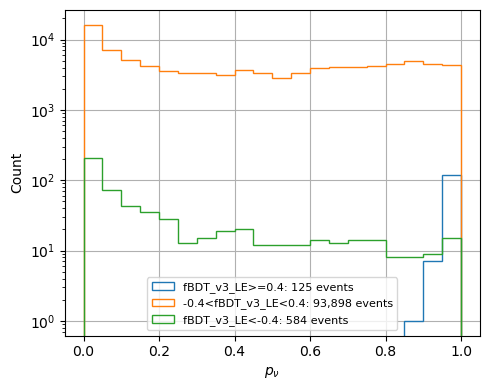

In [ ]:
bdt_cut_min, bdt_cut_max = -0.4, 0.4

fig = plt.figure(figsize=(5,4))
df_main['score'][bdt>=bdt_cut_max].hist(range=(0,1), bins=20, density=False, log=True, histtype='step', label=f"fBDT_v3_LE>={bdt_cut_max}: {(bdt>=bdt_cut_max).sum():,} events")
df_main['score'][(bdt<bdt_cut_max)&(bdt>=bdt_cut_min)].hist(range=(0,1), bins=20, density=False, log=True, histtype='step', label=f"{bdt_cut_min}<fBDT_v3_LE<{bdt_cut_max}: {((bdt<bdt_cut_max)&(bdt>=bdt_cut_min)).sum():,} events")
df_main['score'][(bdt<bdt_cut_min)].hist(range=(0,1), bins=20, density=False, log=True, histtype='step', label=f"fBDT_v3_LE<{bdt_cut_min}: {(bdt<bdt_cut_min).sum():,} events")
plt.legend(fontsize=8)
plt.ylabel("Count")
plt.xlabel(r"$p_\nu$")
plt.tight_layout()
fig = plt.gcf()
save_figure(fig, "preds_distr_bdt_groups.png")

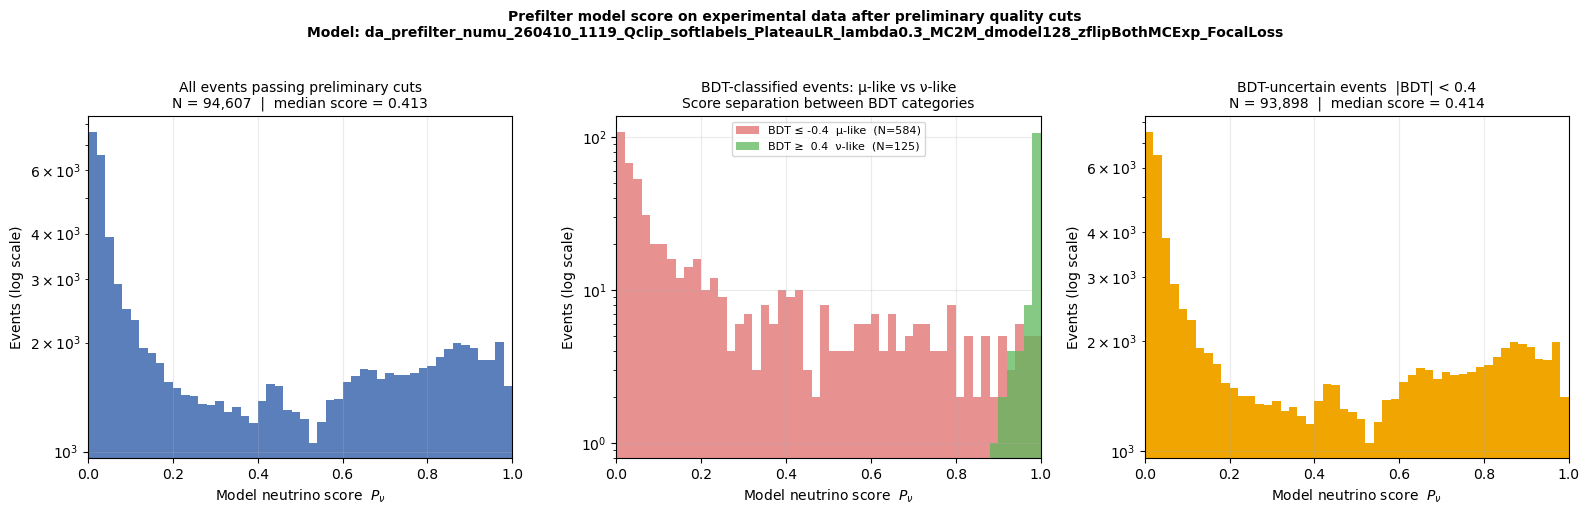

In [ ]:
%matplotlib inline
BINS = 50

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
hist_kw = dict(bins=BINS, range=(0, 1), histtype="bar", edgecolor="none")

# ── Panel 1: All prelim-cut events ───────────────────────────────────────────
axes[0].hist(df_main["score"], log=True, color="#5b7fba", **hist_kw)
axes[0].set_title(
    f"All events passing preliminary cuts\n"
    f"N = {n_all:,}  |  median score = {df_main['score'].median():.3f}",
    fontsize=10,
)

# ── Panel 2: BDT-certain ν vs BDT-certain μ (overlaid) ───────────────────────
axes[1].hist(df_main[mask_mu]["score"],  log=True, color="#e06c6c", alpha=0.75,
             label=f"BDT ≤ -0.4  μ-like  (N={n_mu:,})", **hist_kw)
axes[1].hist(df_main[mask_nu]["score"],  log=True, color="#5cb85c", alpha=0.75,
             label=f"BDT ≥  0.4  ν-like  (N={n_nu:,})", **hist_kw)
axes[1].set_title(
    f"BDT-classified events: μ-like vs ν-like\n"
    f"Score separation between BDT categories",
    fontsize=10,
)
axes[1].legend(fontsize=8)

# ── Panel 3: BDT-uncertain events ────────────────────────────────────────────
axes[2].hist(df_main[mask_unc]["score"], log=True, color="#f0a500", **hist_kw)
axes[2].set_title(
    f"BDT-uncertain events  |BDT| < 0.4\n"
    f"N = {n_unc:,}  |  median score = {df_main[mask_unc]['score'].median():.3f}",
    fontsize=10,
)

for ax in axes:
    ax.set_xlabel("Model neutrino score  $P_{\\nu}$", fontsize=10)
    ax.set_ylabel("Events (log scale)", fontsize=10)
    ax.set_xlim(0, 1)
    ax.grid(alpha=0.25)

fig.suptitle(
    f"Prefilter model score on experimental data after preliminary quality cuts\n"
    f"Model: {MODEL_NAME}",
    fontsize=10, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()

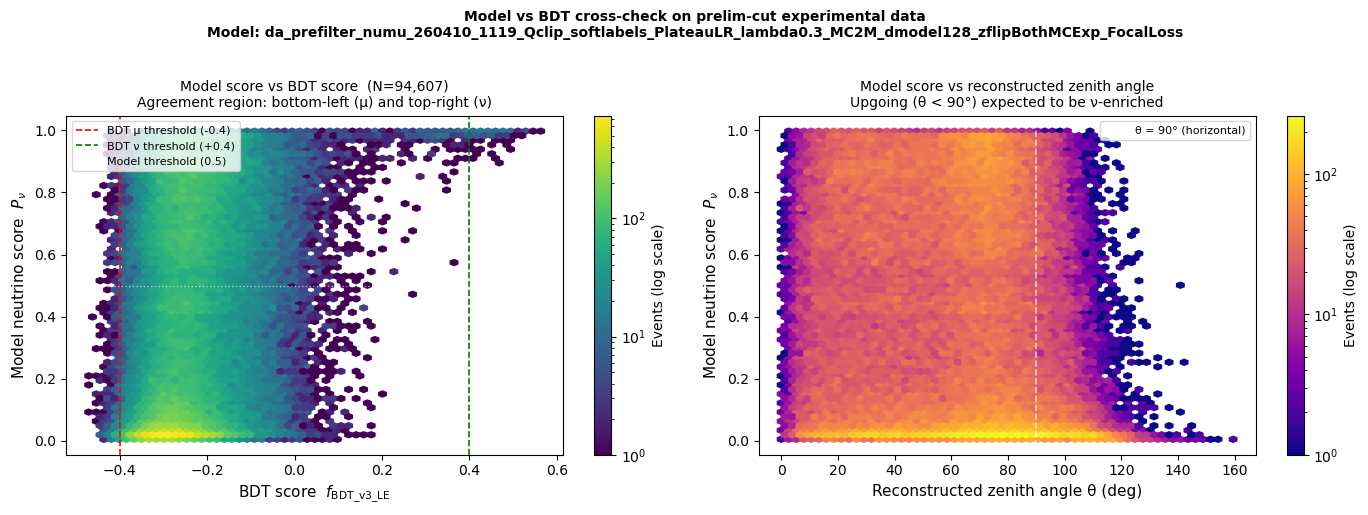

Saved: /home/albert/Baikal2025/experiments/numu/da_prefilter_numu_260410_1119_Qclip_softlabels_PlateauLR_lambda0.3_MC2M_dmodel128_zflipBothMCExp_FocalLoss/figures_test_expnureco/2d_hex_hists.png


In [ ]:
%matplotlib inline

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel 1: 2D hexbin — model score vs BDT score ────────────────────────────
ax = axes[0]
hb = ax.hexbin(
    df_main["fBDT_v3_LE"], df_main["score"],
    gridsize=60, cmap="viridis", bins="log", mincnt=1,
)
fig.colorbar(hb, ax=ax, label="Events (log scale)")
ax.axvline(-0.4, color="red",   lw=1.2, ls="--", label="BDT μ threshold (-0.4)")
ax.axvline( 0.4, color="green", lw=1.2, ls="--", label="BDT ν threshold (+0.4)")
ax.axhline( 0.5, color="white", lw=1.0, ls=":",  alpha=0.6, label="Model threshold (0.5)")
ax.set_xlabel("BDT score  $f_{\\mathrm{BDT\\_v3\\_LE}}$", fontsize=11)
ax.set_ylabel("Model neutrino score  $P_{\\nu}$", fontsize=11)
ax.set_title(
    f"Model score vs BDT score  (N={n_all:,})\n"
    f"Agreement region: bottom-left (μ) and top-right (ν)",
    fontsize=10,
)
ax.legend(fontsize=8, loc="upper left")

# ── Panel 2: model score vs reco theta (upgoing/downgoing separation) ─────────
ax = axes[1]
hb2 = ax.hexbin(
    df_main["thetaRec"], df_main["score"],
    gridsize=60, cmap="plasma", bins="log", mincnt=1,
)
fig.colorbar(hb2, ax=ax, label="Events (log scale)")
ax.axvline(90, color="white", lw=1.2, ls="--", alpha=0.7, label="θ = 90° (horizontal)")
ax.set_xlabel("Reconstructed zenith angle θ (deg)", fontsize=11)
ax.set_ylabel("Model neutrino score  $P_{\\nu}$", fontsize=11)
ax.set_title(
    f"Model score vs reconstructed zenith angle\n"
    f"Upgoing (θ < 90°) expected to be ν-enriched",
    fontsize=10,
)
ax.legend(fontsize=8)

fig.suptitle(
    f"Model vs BDT cross-check on prelim-cut experimental data\n"
    f"Model: {MODEL_NAME}",
    fontsize=10, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()

save_figure(fig, "2d_hex_hists.png")